In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
from pathlib import Path

# Ruta robusta del CSV aunque cambie el directorio de ejecucion
possible_paths = [
    Path("Sample - Superstore.csv"),
    Path("EDA_principiante_1") / "Sample - Superstore.csv"
]

csv_path = next((p for p in possible_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("No se encontro 'Sample - Superstore.csv' en las rutas esperadas.")

df = pd.read_csv(csv_path, encoding="latin1")

df.info() # 20 columns, 9994 rows. No missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
# Limpiar nombres de columnas (quitar espacios, minúsculas)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


In [5]:
df_numeric = df[['profit', 'sales', 'quantity', 'discount']]
df_numeric.head()

,profit,sales,quantity,discount
0,41.9136,261.9600,2,0.00
1,219.5820,731.9400,3,0.00
2,6.8714,14.6200,2,0.00
3,-383.0310,957.5775,5,0.45
4,2.5164,22.3680,2,0.20


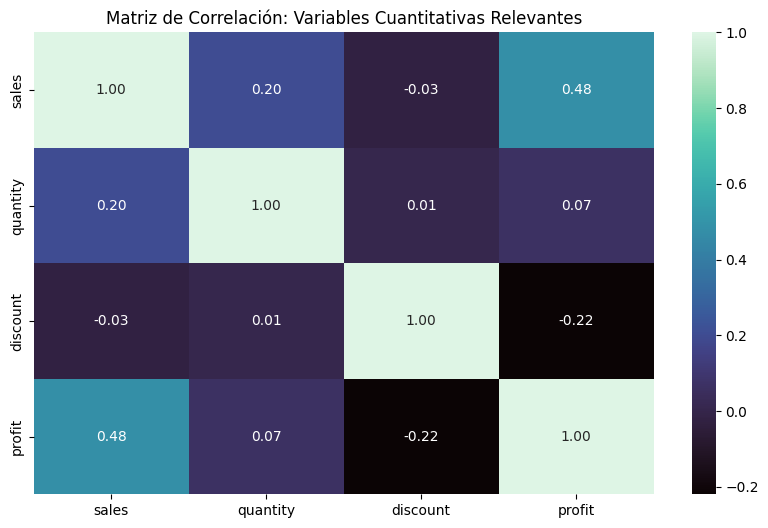

In [6]:
# Mapa de correlaciones
# Se elimina 'row_id' y 'postal_code' ya que no aportan valor analítico
columnas_no_deseadas = ['row_id', 'postal_code']

# Creamos la matriz de correlación excluyendo esas columnas
corr_matrix = df.drop(columns=columnas_no_deseadas).corr(numeric_only=True)

# Graficamos
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='mako', fmt=".2f")
plt.title('Matriz de Correlación: Variables Cuantitativas Relevantes')
plt.show()

## Analisis de descuentos
Se observa que la cantidad de productos vendidos no esta correlacionada con los descuentos. Se analizara en profundidad este aspecto para ver que efecto tienen los descuentos en la compania

In [7]:
df_descuentos = df.groupby('discount').agg({'profit': 'mean', 'quantity': 'sum'}).reset_index()
df_descuentos

,discount,profit,quantity
0,0.00,66.900292,18267
1,0.10,96.055074,373
2,0.15,27.288298,198
3,0.20,24.702572,13660
4,0.30,-45.679636,849
5,0.32,-88.560656,105
6,0.40,-111.927429,786
7,0.45,-226.646464,45
8,0.50,-310.703456,241
9,0.60,-43.077212,501


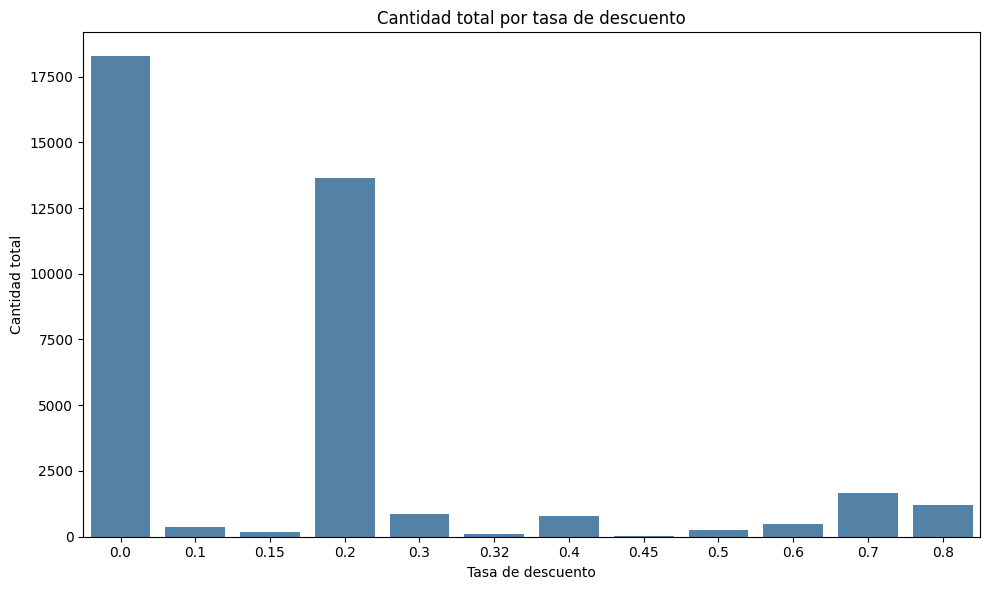

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_descuentos.sort_values('discount'), x='discount', y='quantity', color='steelblue')
plt.title('Cantidad total por tasa de descuento')
plt.xlabel('Tasa de descuento')
plt.ylabel('Cantidad total')
plt.tight_layout()
plt.show()

Vemos que la mayoria de productos se venden sin descuento y que hay bastantes ventas con 20% de descuento

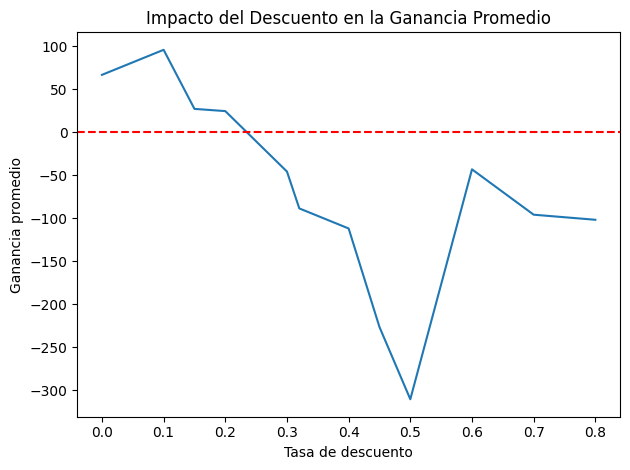

In [9]:
sns.lineplot(data=df_descuentos, x='discount', y='profit')
plt.title('Impacto del Descuento en la Ganancia Promedio')
plt.axhline(0, color='red', linestyle='--') # Línea de pérdida
plt.xlabel('Tasa de descuento')
plt.ylabel('Ganancia promedio')
plt.tight_layout()
plt.show()

Se observa que hay una tendencia general que a mayor descuento menos ganancias. Ademas, ya se observo que la mayoria de productos se venden a 20% de descuento o menos, y a esta altura ganancia esta por encima de 0


## Analsis por Categoria: ¿Dónde estamos perdiendo dinero?


Top 5 de Subcategorías con más pérdidas:
           category sub-category      profit
3         Furniture       Tables -17725.4811
0         Furniture    Bookcases  -3472.5560
12  Office Supplies     Supplies  -1189.0995
8   Office Supplies    Fasteners    949.5182
15       Technology     Machines   3384.7569


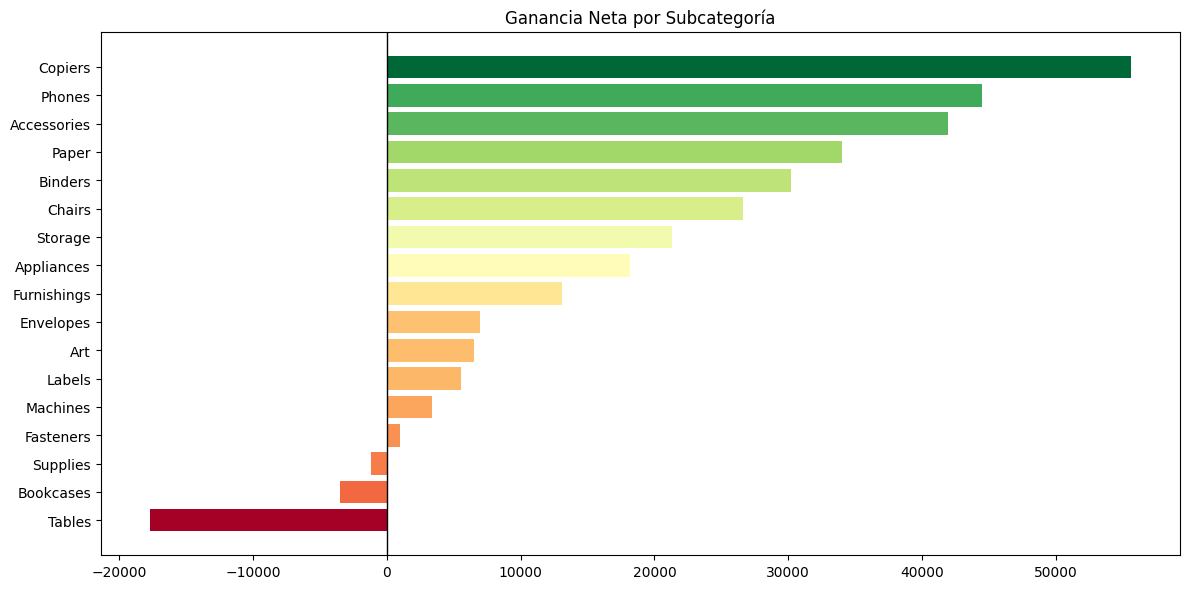

In [10]:
# Agrupar por Categoría y Subcategoría, sumando la ganancia
cat_profit = df.groupby(['category', 'sub-category'])['profit'].sum().reset_index()

# Ordenar de mayor pérdida a mayor ganancia
cat_profit = cat_profit.sort_values(by='profit')

print("Top 5 de Subcategorías con más pérdidas:")
print(cat_profit.head())

# Colores: valores bajos en rojo y altos en verde
norm = plt.Normalize(cat_profit['profit'].min(), cat_profit['profit'].max())
bar_colors = plt.cm.RdYlGn(norm(cat_profit['profit'].values))

# Visualización rápida
plt.figure(figsize=(12, 6))
plt.barh(cat_profit['sub-category'], cat_profit['profit'], color=bar_colors)
plt.title('Ganancia Neta por Subcategoría')
plt.axvline(0, color='black', lw=1)
plt.tight_layout()
plt.show()

La categoria que genera mas perdidas es 'Tables' con bastante diferencia. Por que?

### Descuentos culpables?

Impacto del Descuento en Tablas:
   discount  quantity      profit
0      0.00       310  184.393051
1      0.20       281   -4.275465
2      0.30       180  -63.006067
3      0.40       292 -215.831957
4      0.45        45 -226.646464
5      0.50       133 -239.316314


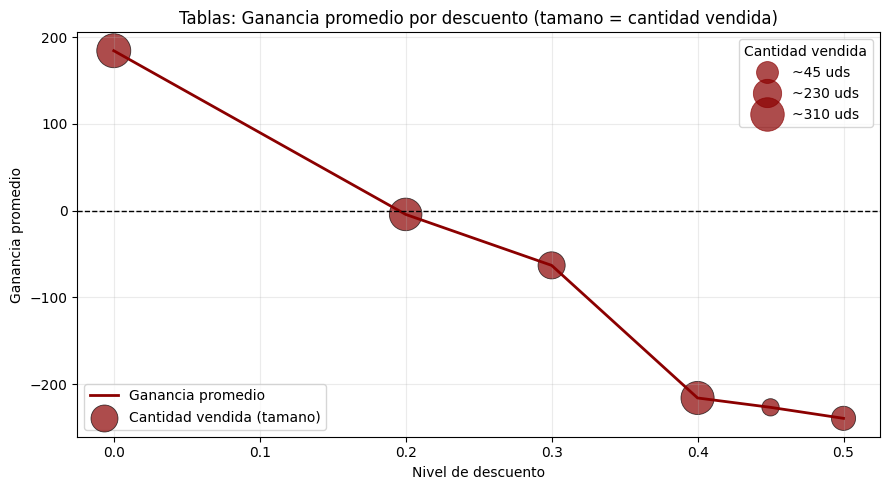

In [11]:
# Filtramos solo para la subcategoria de Tablas
df_tables = df[df['sub-category'] == 'Tables']

# Calculamos cantidad vendida y ganancia promedio por nivel de descuento
discount_impact = (
    df_tables.groupby('discount', as_index=False)
    .agg(quantity=('quantity', 'sum'), profit=('profit', 'mean'))
    .sort_values('discount')
)

print("Impacto del Descuento en Tablas:")
print(discount_impact)

# Grafico de linea (ganancia promedio) con tamano de puntos segun cantidad vendida
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=discount_impact,
    x='discount',
    y='profit',
    color='darkred',
    linewidth=2,
    marker='o',
    markersize=0,
    ax=ax,
    label='Ganancia promedio'
)

size_min, size_max = 80, 600
scatter = ax.scatter(
    discount_impact['discount'],
    discount_impact['profit'],
    s=(discount_impact['quantity'] / discount_impact['quantity'].max()) * (size_max - size_min) + size_min,
    color='darkred',
    alpha=0.7,
    edgecolor='black',
    linewidth=0.6,
    label='Cantidad vendida (tamano)'
)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Tablas: Ganancia promedio por descuento (tamano = cantidad vendida)')
ax.set_xlabel('Nivel de descuento')
ax.set_ylabel('Ganancia promedio')
ax.grid(True, alpha=0.25)

# Leyenda para tamanos de puntos
qty_levels = [
    int(discount_impact['quantity'].min()),
    int(discount_impact['quantity'].median()),
    int(discount_impact['quantity'].max())
]
handles, labels = scatter.legend_elements(
    prop='sizes',
    num=3,
    alpha=0.7,
    color='darkred',
    func=lambda s: ((s - size_min) / (size_max - size_min)) * discount_impact['quantity'].max()
)
size_legend = ax.legend(handles, [f'~{q} uds' for q in qty_levels], title='Cantidad vendida', loc='upper right')
ax.add_artist(size_legend)
ax.legend(loc='lower left')

fig.tight_layout()
plt.show()

Vemos que las tablas con descuentos altos tienden a perder dinero, y que hay bastantes ventas en esos niveles de descuento. Se observa que las ganancias pasan a ser negativas al 20%. Se obtendran la cantidad de ventas con 20% de descuento o menor, y la cantidad de ventas con descuento mayor al 20%

In [12]:
# Resumen de cantidad vendida por grupo de descuento (a partir de discount_impact)
resumen_descuento = (
    discount_impact.assign(
        grupo_descuento=discount_impact['discount'].apply(
            lambda x: '20% o menor' if x <= 0.20 else 'Mayor al 20%'
        )
    )
    .groupby('grupo_descuento', as_index=False)['quantity']
    .sum()
    .rename(columns={'quantity': 'cantidad_vendida'})
)

resumen_descuento

,grupo_descuento,cantidad_vendida
0,20% o menor,591
1,Mayor al 20%,650


Se puede notar que se venden mas productos con un descuento mayor al 20% (mas perdida) que menor. Por ende los descuentos parecen ser gran responsable de las perdidas en la categoria 'Tables'.

El margen de contribución de las mesas no soporta descuentos superiores al 10-15%, por ende se sugeriría limitar el descuento máximo en la categoría "Tables" a un 10% y reducir su produccion

## Analisis Geografico

In [13]:
# Agrupar por Estado
state_analysis = df.groupby('state').agg({'sales': 'sum', 'profit': 'sum'}).reset_index()

# Ordenar por Ventas de mayor a menor
state_analysis = state_analysis.sort_values(by='sales', ascending=False)

# Filtrar estados con ganancias negativas
estados_perdida = state_analysis[state_analysis['profit'] < 0]

# Comparación de Descuento Promedio: Texas vs Resto del País
avg_discount = df.groupby('state')['discount'].mean().sort_values(ascending=False)


from IPython.core.display import display_html

# 1. Preparamos las tablas (asegurándonos de que sean DataFrames)
df1 = estados_perdida.head().reset_index()
df2 = avg_discount.head().reset_index()
df2.columns = ['state', 'avg_discount'] # Renombramos para claridad

# 2. Convertimos los DataFrames a HTML
df1_styler = df1.style.set_table_attributes("style='display:inline'").set_caption('Top 5 Estados con más Pérdida')
df2_styler = df2.style.set_table_attributes("style='display:inline'").set_caption('Top 5 Estados con más Descuento')

# 3. Los mostramos juntos usando un truco de HTML/CSS
display_html(df1_styler._repr_html_() + " &nbsp;&nbsp;&nbsp; " + df2_styler._repr_html_(), raw=True)


Top 5 Estados con más Pérdida 
 
 
   
 index 
 state 
 sales 
 profit 
 
 
 
 
 0 
 41 
 Texas 
 170188.045800 
 -25729.356300 
 
 
 1 
 36 
 Pennsylvania 
 116511.914000 
 -15559.960300 
 
 
 2 
 8 
 Florida 
 89473.708000 
 -3399.301700 
 
 
 3 
 11 
 Illinois 
 80166.101000 
 -12607.887000 
 
 
 4 
 33 
 Ohio 
 78258.136000 
 -16971.376600 
 
 
 
     
 
 Top 5 Estados con más Descuento 
 
 
   
 state 
 avg_discount 
 
 
 
 
 0 
 Illinois 
 0.390041 
 
 
 1 
 Texas 
 0.370193 
 
 
 2 
 Pennsylvania 
 0.328620 
 
 
 3 
 Ohio 
 0.324947 
 
 
 4 
 Colorado 
 0.316484

En la tabla de la izquierda se ven los estados con mas volumen de venta de los que tienen ganancia negativa (perdida). A la derecha, se ven los estados con mas descuento promedio. 

Se concluye que en los estados Texas, Pennsylvania, Ohio e Illinois se genera mucha perdida por los altos descuentos. Otra vez se hace notar el gran efecto que tienen los descuentos en las perdidas.

## Executive Dashboard
Resumen visual de hallazgos clave: descuentos, rentabilidad por categoria/subcategoria y focos geograficos de perdida.

KPI Summary


,metrica,valor
0,Ventas totales,2.297201e+06
1,Ganancia total,2.863970e+05
2,Descuento promedio,1.562027e-01
3,Pedidos con descuento > 20%,1.393836e-01
4,Ganancia total subcategoria Tables,-1.772548e+04


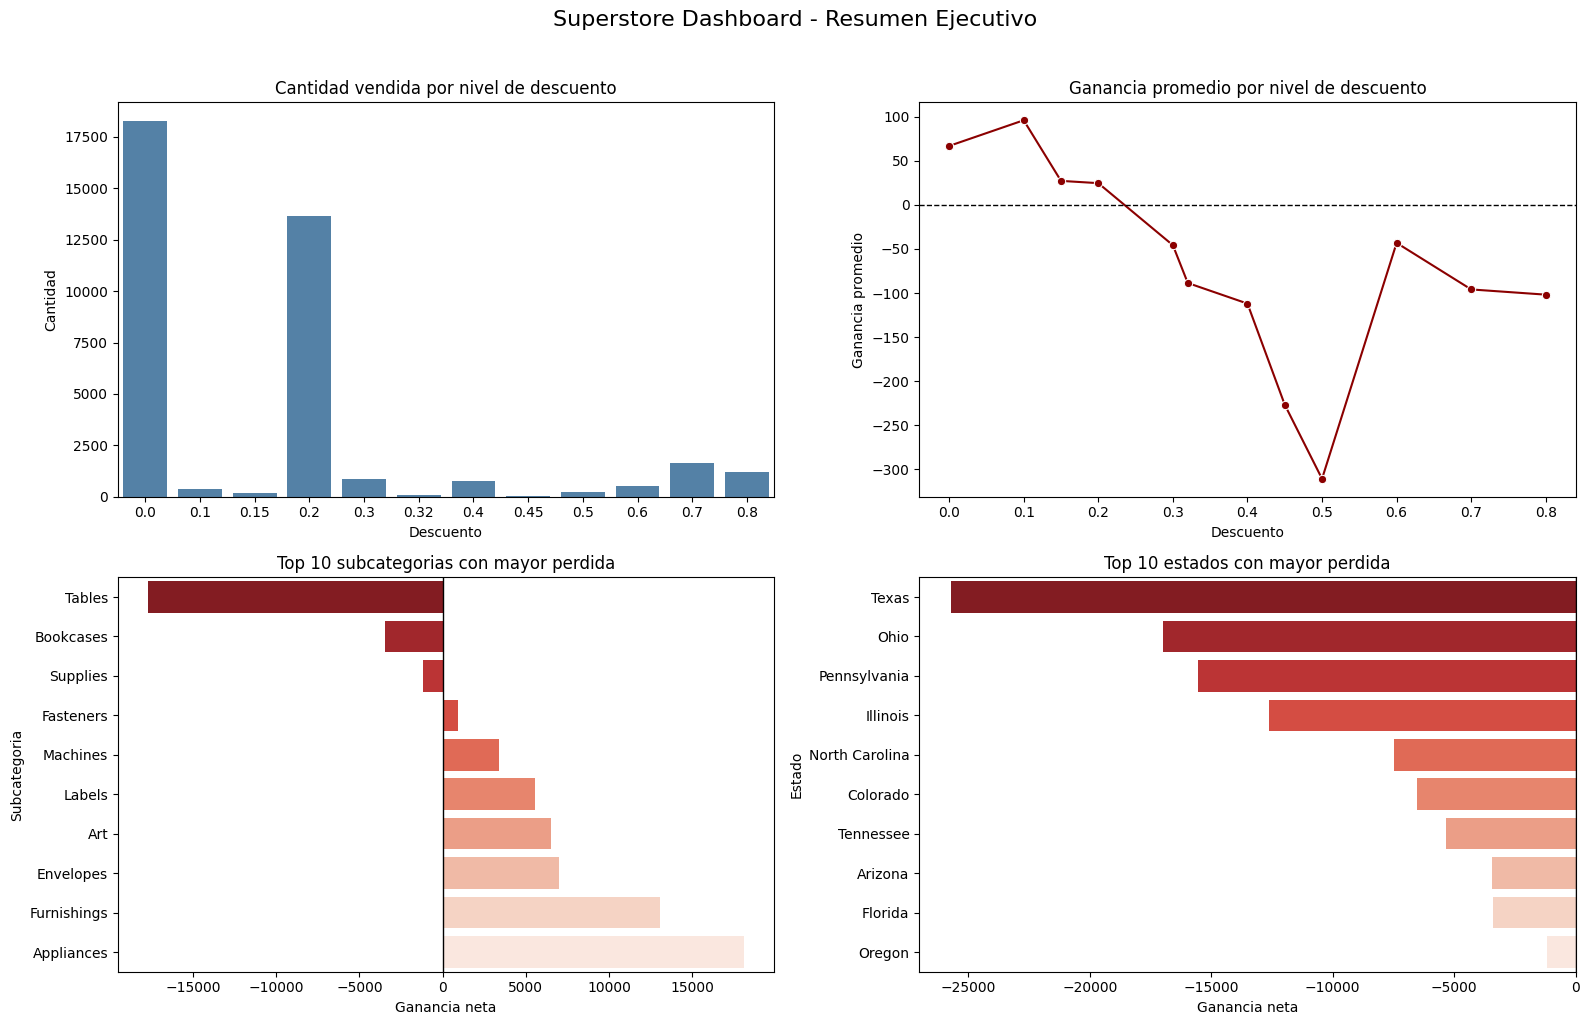

In [14]:
import warnings
warnings.filterwarnings('ignore')

# Dashboard: KPIs + visual resumen
kpi = pd.DataFrame({
    'metrica': [
        'Ventas totales',
        'Ganancia total',
        'Descuento promedio',
        'Pedidos con descuento > 20%',
        'Ganancia total subcategoria Tables'
    ],
    'valor': [
        df['sales'].sum(),
        df['profit'].sum(),
        df['discount'].mean(),
        (df['discount'] > 0.20).mean(),
        df[df['sub-category'] == 'Tables']['profit'].sum()
    ]
})

print('KPI Summary')
display(kpi)

# Datos auxiliares
profit_by_discount = df.groupby('discount', as_index=False)['profit'].mean().sort_values('discount')
qty_by_discount = df.groupby('discount', as_index=False)['quantity'].sum().sort_values('discount')
cat_profit = df.groupby(['category', 'sub-category'], as_index=False)['profit'].sum().sort_values('profit')
state_profit = df.groupby('state', as_index=False)['profit'].sum().sort_values('profit')

top_loss_subcats = cat_profit.head(10)
top_loss_states = state_profit.head(10)

# Figura de dashboard
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# 1) Cantidad por descuento
sns.barplot(data=qty_by_discount, x='discount', y='quantity', color='steelblue', ax=axs[0, 0])
axs[0, 0].set_title('Cantidad vendida por nivel de descuento')
axs[0, 0].set_xlabel('Descuento')
axs[0, 0].set_ylabel('Cantidad')

# 2) Ganancia promedio por descuento
sns.lineplot(data=profit_by_discount, x='discount', y='profit', marker='o', color='darkred', ax=axs[0, 1])
axs[0, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axs[0, 1].set_title('Ganancia promedio por nivel de descuento')
axs[0, 1].set_xlabel('Descuento')
axs[0, 1].set_ylabel('Ganancia promedio')

# 3) Subcategorias con mas perdida
sns.barplot(data=top_loss_subcats, x='profit', y='sub-category', palette='Reds_r', ax=axs[1, 0])
axs[1, 0].axvline(0, color='black', linewidth=1)
axs[1, 0].set_title('Top 10 subcategorias con mayor perdida')
axs[1, 0].set_xlabel('Ganancia neta')
axs[1, 0].set_ylabel('Subcategoria')

# 4) Estados con mas perdida
sns.barplot(data=top_loss_states, x='profit', y='state', palette='Reds_r', ax=axs[1, 1])
axs[1, 1].axvline(0, color='black', linewidth=1)
axs[1, 1].set_title('Top 10 estados con mayor perdida')
axs[1, 1].set_xlabel('Ganancia neta')
axs[1, 1].set_ylabel('Estado')

plt.suptitle('Superstore Dashboard - Resumen Ejecutivo', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones Finales
1. Los descuentos altos estan directamente asociados con menor rentabilidad, y en varios niveles superan el punto de equilibrio (ganancia promedio negativa).
2. La subcategoria `Tables` es el principal foco de perdida; su volumen de ventas con descuentos altos agrava el impacto economico.
3. A nivel geografico, hay estados con volumen relevante y ganancias negativas, lo que sugiere una combinacion de politica comercial agresiva y/o estructura de costos desfavorable.
4. Recomendaciones prioritarias:
   - Limitar descuentos por encima de 20% en productos sensibles a margen (especialmente `Tables`).
   - Definir techos de descuento por categoria/subcategoria segun margen historico.
   - Revisar estrategia por estado con perdida persistente (precio, mix de producto y costo logistico).
5. Proximo paso analitico sugerido: modelar elasticidad precio-demanda por subcategoria para estimar el descuento optimo que maximice utilidad y no solo volumen.